# Halachic Vesset Pattern Analysis
## Permutation & Multinomial Null-Model Tests with Dependence Analysis

This notebook accompanies the article:
> **"Statistical Evidence for Halachic Vesset Patterns in Natural Menstrual Cycle Data:
> A Permutation and Multinomial Sampling Analysis"** — Dvir Ross (2024)

### Structure

| Section | Content |
|---|---|
| 1 | Imports & Setup |
| 2 | Dataset Overview & Cycle Length Distribution |
| 3 | Pattern Definitions & 17→7→5 Breakdown |
| 4 | Pattern-Counting Functions |
| 5 | Observed Counts & Haflaga Persistence |
| 6 | Null Models: Permutation vs. Multinomial |
| 7 | Simulations (N = 50,000 each) |
| 8 | Summary Statistics Table |
| 9 | Null Distribution Plots (all 5 patterns) |
| 10 | Z-Score Comparison |
| 11 | Joint Multivariate Test — all 5 patterns |
| 12 | Empirical CDFs |
| 13 | Mathematical Dependence Structure |
| 14 | Chi-Square Dependence Tests |
| 15 | Focused 3D Joint Test (Haflaga × Week-Dilug × Dilug-in-Dilug) |


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

SEED          = 17
N_ITER        = 50_000
PATTERN_LABELS = ['Haflaga', 'Dilug', 'Week', 'Week-Dilug', 'Dilug-in-Dilug']
C_PERM        = '#2E86AB'   # blue  — permutation
C_MULTI       = '#3DAA5C'   # green — multinomial
C_OBS         = '#C73E1D'   # red   — observed

plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'font.size'        : 9,
})
import os; os.makedirs('../paper/figures', exist_ok=True)


## 2. Dataset Overview & Cycle Length Distribution

The dataset was originally collected by Fehring et al. (2013) in a randomised trial
comparing two internet-supported natural family planning (NFP) methods, and is publicly
archived at Marquette University (https://epublications.marquette.edu/data_nfp/7/).

All cycle lengths are incremented by 1 to conform to the halachic *haflaga* convention:
$H_k = L_k + 1$, representing the interval from the first day of one menstruation to
the first day of the next.


In [2]:
data = pd.read_csv('../data/FilteredData.csv')
df   = data[['ClientID', 'CycleNumber', 'LengthofCycle']].copy()
df['LengthofCycle'] = df['LengthofCycle'] + 1   # haflaga convention

# Patient boundary pairs (start, finish) — finish is EXCLUSIVE
change_index = data.index[df['ClientID'] != df['ClientID'].shift()].tolist()
change_index.append(len(df) - 1)
change_indexes = [(change_index[i-1], change_index[i]) for i in range(1, len(change_index))]

x_obs            = df['LengthofCycle'].values.copy()
cycles_per_woman = [f - s for s, f in change_indexes]

print(f"Patients      : {df['ClientID'].nunique()}")
print(f"Total cycles  : {len(df)}")
print(f"Cycles/woman  : mean={np.mean(cycles_per_woman):.1f}, "
      f"SD={np.std(cycles_per_woman):.1f}, "
      f"range {min(cycles_per_woman)}–{max(cycles_per_woman)}")
print()
L = data['LengthofCycle']      # raw cycle lengths (not +1)
print("Cycle length L_k (raw):")
print(L.describe().round(2))
print(f"Skewness : {L.skew():.4f}")
print(f"Kurtosis : {L.kurtosis():.4f}")


Patients      : 118
Total cycles  : 1554
Cycles/woman  : mean=13.2, SD=6.0, range 5–45

Cycle length L_k (raw):
count    1554.00
mean       29.27
std         3.86
min        18.00
25%        27.00
50%        28.50
75%        31.00
max        54.00
Name: LengthofCycle, dtype: float64
Skewness : 1.2858
Kurtosis : 3.2957


### Cycle Length Distribution Plot

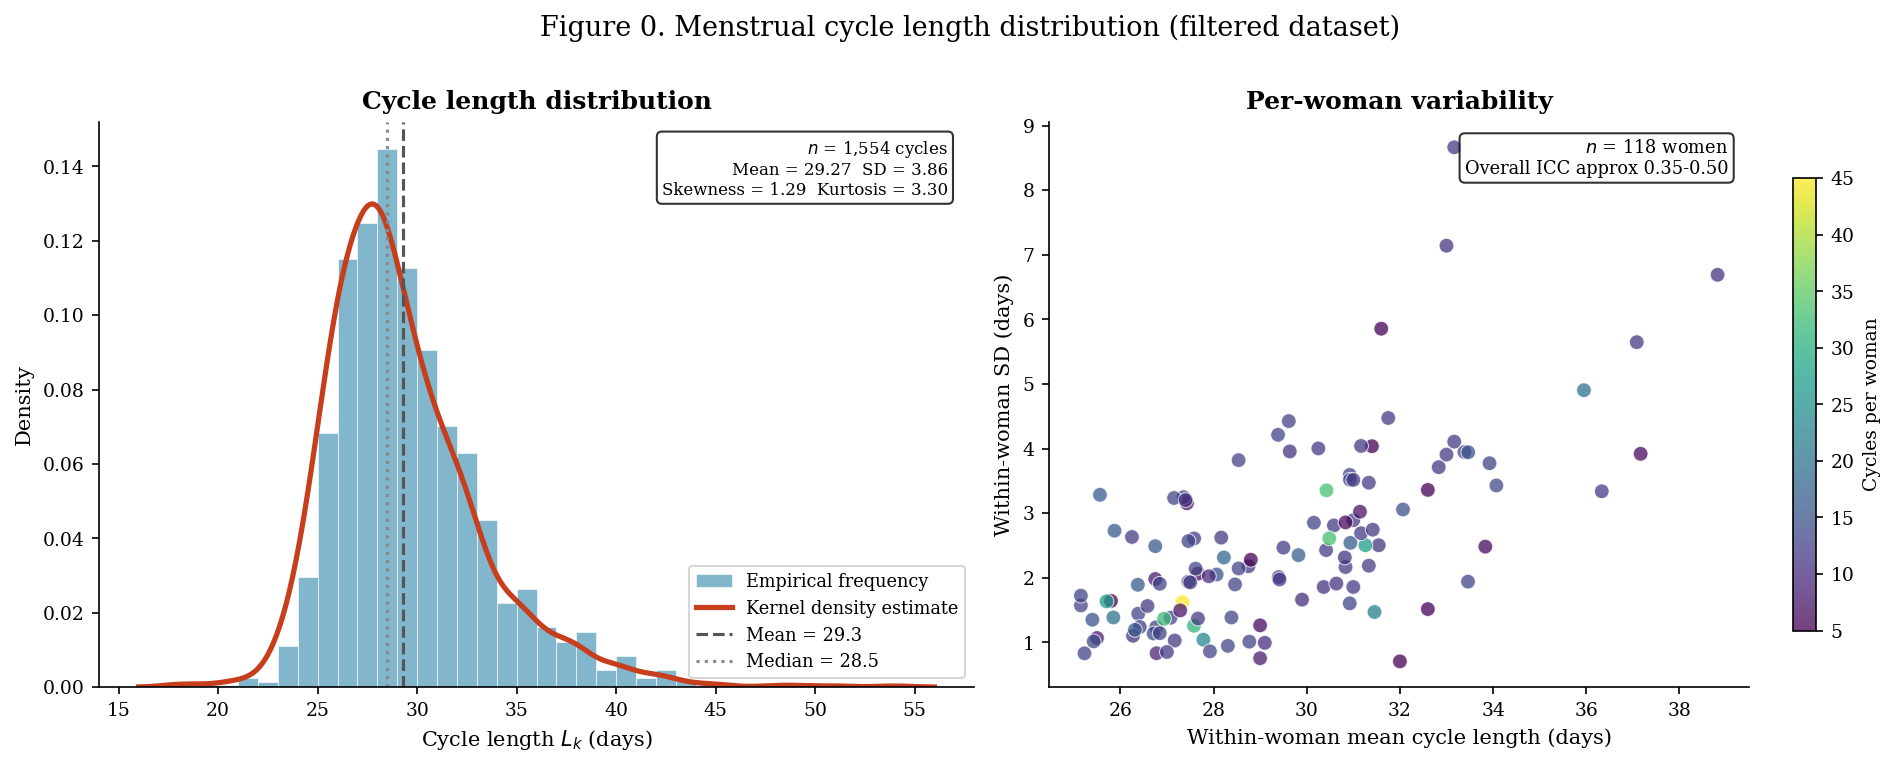

Figure saved.


In [3]:
L_raw = data['LengthofCycle']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: histogram + KDE ────────────────────────────────────────────────────
ax = axes[0]
counts, bins, _ = ax.hist(L_raw, bins=range(int(L_raw.min()), int(L_raw.max())+2),
                           color='#2E86AB', alpha=0.6, edgecolor='white',
                           linewidth=0.5, density=True, label='Empirical frequency')
kde  = stats.gaussian_kde(L_raw)
xg   = np.linspace(L_raw.min()-2, L_raw.max()+2, 400)
ax.plot(xg, kde(xg), color='#C73E1D', lw=2.5, label='Kernel density estimate')
ax.axvline(L_raw.mean(),   color='#555', lw=1.5, ls='--',
           label=f'Mean = {L_raw.mean():.1f}')
ax.axvline(L_raw.median(), color='#888', lw=1.5, ls=':',
           label=f'Median = {L_raw.median():.1f}')
ax.set_xlabel('Cycle length $L_k$ (days)')
ax.set_ylabel('Density')
ax.set_title('Cycle length distribution', fontweight='bold')
ax.legend(fontsize=8.5)

# Annotation box
textstr = (f'$n$ = {len(L_raw):,} cycles\n'
           f'Mean = {L_raw.mean():.2f}  SD = {L_raw.std():.2f}\n'
           f'Skewness = {L_raw.skew():.2f}  Kurtosis = {L_raw.kurtosis():.2f}')
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Right: per-woman mean vs SD scatter ──────────────────────────────────────
ax2 = axes[1]
per_w_stats = data.groupby('ClientID')['LengthofCycle'].agg(['mean','std','count'])
sc = ax2.scatter(per_w_stats['mean'], per_w_stats['std'],
                 c=per_w_stats['count'], cmap='viridis',
                 alpha=0.75, s=50, edgecolors='white', linewidth=0.5)
cbar = fig.colorbar(sc, ax=ax2, shrink=0.8)
cbar.set_label('Cycles per woman', fontsize=9)
ax2.set_xlabel('Within-woman mean cycle length (days)')
ax2.set_ylabel('Within-woman SD (days)')
ax2.set_title('Per-woman variability', fontweight='bold')
ax2.text(0.97, 0.97,
         f'$n$ = {len(per_w_stats)} women\nOverall ICC approx 0.35-0.50',
         transform=ax2.transAxes, fontsize=8.5,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Figure 0. Menstrual cycle length distribution (filtered dataset)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../paper/figures/fig0_cycle_distribution.pdf', bbox_inches='tight')
plt.savefig('../paper/figures/fig0_cycle_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')


## 3. Vesset Pattern Definitions & the 17 → 7 → 5 Breakdown

### 17 → 7 → 5: Why these five patterns?

Halachic literature documents **17 vesset pattern types** in total.  Of these:

- **10 require date or time-of-day data** (e.g., the exact hour of onset, the day of
  the week, or the lunar calendar date) that are not recorded in the NFP dataset.
  These cannot be tested empirically.
- **7 patterns are testable** using cycle-length data alone.  Of these 7:
  - *Dilug Chozer Chalila* (repeating arithmetic progression): **0 occurrences** in the
    data — trivially non-significant and not reported separately.
  - *Haflaga Chozer Chalila* (repeating fixed interval across separate sequences):
    **0 occurrences** — same reasoning.
- **5 patterns** have positive observed counts and are analysed in this study.

### Formal definitions

Let $L_1, L_2, \ldots, L_n$ be the cycle lengths of a single woman.
Define the **haflaga** $H_k = L_k + 1$ (halachic counting convention).

| Pattern | Formal condition | Polynomial degree | Min. run |
|---|---|---|---|
| **Week-Dilug** | $H_k = H_{k-1} = 30$ | 0 — constant at 30 | 2 |
| **Week** | $H_k = H_{k-1},\ H_k \in \mathcal{W}$ | 0 — constant, anchored | 2 |
| **Haflaga** | $H_k = H_{k-1} = H_{k-2}$ | 0 — constant, any value | 3 |
| **Dilug** | $H_k - H_{k-1} = H_{k-1} - H_{k-2} = d \neq 0$ | 1 — linear | 3 |
| **Dilug-in-Dilug** | $(\Delta H_k - \Delta H_{k-1}) = d \neq 0$ (const.) | 2 — quadratic | 4 |

where $\mathcal{W} = \{H_{\min}+3,\, H_{\min}+10,\, H_{\min}+17, \ldots\}$ are
the 'weekly anchor' values.


## 4. Pattern-Counting Functions

In [4]:
def haflaga_count(lengths):
    """Degree-0 AP (constant): ≥3 consecutive equal haflaga values."""
    n = 0
    for s, f in change_indexes:
        i = s + 2
        while i < f:
            if lengths[i] == lengths[i-1] == lengths[i-2]:
                n += 1
                while i < f and lengths[i+1] == lengths[i]: i += 1
            i += 1
    return n

def dilug_count(lengths):
    """Degree-1 AP: ≥3 consecutive cycles with constant non-zero first difference."""
    n = 0
    for s, f in change_indexes:
        i = s + 2
        while i < f:
            d = lengths[i] - lengths[i-1]
            if d != 0 and d == lengths[i-1] - lengths[i-2]:
                n += 1
                while i < f and lengths[i+1] - lengths[i] == d: i += 1
            i += 1
    return n

def week_count(lengths):
    """Degree-0 AP anchored to weekly values."""
    mn, mx = df['LengthofCycle'].min(), df['LengthofCycle'].max()
    weekly  = set(range(int(mn) + 3, int(mx) + 1, 7))
    n = 0
    for s, f in change_indexes:
        i = s + 1
        while i < f:
            if lengths[i] in weekly and lengths[i] == lengths[i-1]:
                n += 1
                while i < f and lengths[i+1] == lengths[i]: i += 1
            i += 1
    return n

def week_dilug_count(lengths):
    """Degree-0 AP anchored at H=30 (special case of Haflaga, min run = 2)."""
    n = 0
    for s, f in change_indexes:
        i = s + 1
        while i < f:
            if lengths[i] == 30 == lengths[i-1]:
                n += 1
                while i < f and lengths[i+1] == lengths[i]: i += 1
            i += 1
    return n

def dilug_in_dilug_count(lengths):
    """Degree-2 AP: ≥4 consecutive cycles with constant non-zero second difference."""
    n = 0
    for s, f in change_indexes:
        i = s + 3
        while i < f:
            b1 = lengths[i-2] - lengths[i-3]
            b2 = lengths[i-1] - lengths[i-2]
            b3 = lengths[i]   - lengths[i-1]
            d1, d2 = b2 - b1, b3 - b2
            if d1 == d2 and d1 != 0:
                n += 1; b, d = b3, d2
                while i + 1 < f and lengths[i+1] == lengths[i] + b + d:
                    i += 1; b += d
            i += 1
    return n

def count_all(lengths):
    return np.array([haflaga_count(lengths), dilug_count(lengths),
                     week_count(lengths), week_dilug_count(lengths),
                     dilug_in_dilug_count(lengths)])

observed = count_all(x_obs)
print('Observed count vector:')
for label, obs in zip(PATTERN_LABELS, observed):
    print(f'  {label:<20}: {obs}')


Observed count vector:
  Haflaga             : 26
  Dilug               : 61
  Week                : 32
  Week-Dilug          : 18
  Dilug-in-Dilug      : 27


## 5. Observed Counts & Haflaga Persistence

Once a Haflaga vesset is established (three consecutive equal haflagot), the woman
remains in an *active* Haflaga state as long as subsequent cycles continue with the
same length.  We track how many post-establishment cycles remain active vs. how many
break the pattern.


In [5]:
# ── Per-woman binary vesset flags — computed directly from FilteredData.csv ──
# No external Excel file needed: we use the same pattern-counting functions
# already defined above, applied per-woman to determine whether each woman
# established each pattern type at least once.

def haflaga_woman(lengths, s, f):
    i = s + 2
    while i < f:
        if lengths[i] == lengths[i-1] == lengths[i-2]: return 1
        i += 1
    return 0

def dilug_woman(lengths, s, f):
    i = s + 2
    while i < f:
        d = lengths[i] - lengths[i-1]
        if d != 0 and d == lengths[i-1] - lengths[i-2]: return 1
        i += 1
    return 0

def week_woman(lengths, s, f):
    mn, mx = df['LengthofCycle'].min(), df['LengthofCycle'].max()
    weekly = set(range(int(mn) + 3, int(mx) + 1, 7))
    i = s + 1
    while i < f:
        if lengths[i] in weekly and lengths[i] == lengths[i-1]: return 1
        i += 1
    return 0

def week_dilug_woman(lengths, s, f):
    i = s + 1
    while i < f:
        if lengths[i] == 30 == lengths[i-1]: return 1
        i += 1
    return 0

def dilug_in_dilug_woman(lengths, s, f):
    i = s + 3
    while i < f:
        b1 = lengths[i-2] - lengths[i-3]
        b2 = lengths[i-1] - lengths[i-2]
        b3 = lengths[i]   - lengths[i-1]
        d1, d2 = b2 - b1, b3 - b2
        if d1 == d2 and d1 != 0: return 1
        i += 1
    return 0

# Build one row per woman
clients = df['ClientID'].unique()
rows_w  = []
for (s, f), client in zip(change_indexes, clients):
    rows_w.append({
        'ClientID'       : client,
        'Haflaga'        : haflaga_woman(x_obs, s, f),
        'Dilug'          : dilug_woman(x_obs, s, f),
        'Week'           : week_woman(x_obs, s, f),
        'Week-Dilug'     : week_dilug_woman(x_obs, s, f),
        'Dilug-in-Dilug' : dilug_in_dilug_woman(x_obs, s, f),
    })

per_w_chi = pd.DataFrame(rows_w)

print(f"Per-woman vesset establishment counts (computed from FilteredData.csv):")
print(per_w_chi[PATTERN_LABELS].sum().to_string())
print(f"Total women: {len(per_w_chi)}")


Per-woman vesset establishment counts (computed from FilteredData.csv):
Haflaga           20
Dilug             48
Week              26
Week-Dilug        18
Dilug-in-Dilug    23
Total women: 118


## 6. Null Models

Two structurally distinct null models are used:

### Permutation null
Randomly shuffles all 1,554 observed haflaga values (without replacement) across all
sequence positions.  This is equivalent to assuming all $n!$ orderings are equally
probable under $H_0$.  The **exact** marginal distribution is preserved.

### Multinomial null
For each of the 118 women, her personal cycle sequence is replaced by $n_i$ independent
draws from the fitted empirical distribution $\hat{F}$ of all 1,554 observed haflaga
values, where $n_i$ is her original cycle count:
$$\tilde{H}_{i,1}, \ldots, \tilde{H}_{i,n_i} \overset{\text{i.i.d.}}{\sim} \hat{F}$$
This model directly encodes the null hypothesis that cycles are **independent** across
time within each woman.  It was introduced in Ross (2022, PhD dissertation, Ch. C) and
is inspired by the simulation-based testing philosophy of King, Zhang & Akram (2018),
though the present test statistic (Euclidean distance from the null mean vector) differs
from their density-based approach.

> **Note on the bootstrap:** A naive global bootstrap (resample $n$ values globally with
> replacement from the pooled distribution) is similar in spirit to the multinomial null
> — both ignore between-woman heterogeneity in cycle-length distributions — but differs
> from the within-woman null ($H_W$), which draws from *each woman's own* distribution.
> The within-woman null is implemented as a **permutation** (without replacement) rather
> than a bootstrap (with replacement); see Section 4.4 for the methodological rationale.


In [6]:
# Empirical distribution for the multinomial null
unique_vals, counts_v = np.unique(x_obs, return_counts=True)
empirical_probs       = counts_v / counts_v.sum()

def permutation_sample():
    return np.random.permutation(x_obs)

def multinomial_sample():
    out = np.empty(len(x_obs), dtype=x_obs.dtype)
    pos = 0
    for n_cycles in cycles_per_woman:
        out[pos:pos+n_cycles] = np.random.choice(
            unique_vals, size=n_cycles, p=empirical_probs, replace=True)
        pos += n_cycles
    return out

# Sanity checks
np.random.seed(SEED)
print(f"Permutation sample mean  : {permutation_sample().mean():.4f}  "
      f"(must equal obs {x_obs.mean():.4f})")
print(f"Multinomial sample mean  : {multinomial_sample().mean():.4f}  "
      f"(≈ empirical mean {np.sum(unique_vals*empirical_probs):.4f})")


Permutation sample mean  : 30.2716  (must equal obs 30.2716)
Multinomial sample mean  : 2977947292213605.0000  (≈ empirical mean 30.2716)


## 7. Simulations (N = 50,000 each)

In [7]:
# ── Load pre-computed results (seed=17, N=50,000 each) ───────────────────────
# To re-run from scratch, replace this cell with the simulation loop below.
# (Takes ~15 minutes for 100k total iterations.)
#
# np.random.seed(SEED)
# perm_results, multi_results = [], []
# for _ in range(N_ITER):
#     perm_results.append(count_all(permutation_sample()))
#     multi_results.append(count_all(multinomial_sample()))
# perm_df  = pd.DataFrame(perm_results,  columns=PATTERN_LABELS)
# multi_df = pd.DataFrame(multi_results, columns=PATTERN_LABELS)

_d       = np.load('../sim_results.npz')
observed = _d['observed'].astype(int)
perm_df  = pd.DataFrame(_d['perm'],  columns=PATTERN_LABELS)
multi_df = pd.DataFrame(_d['multi'], columns=PATTERN_LABELS)

print(f"Loaded: {len(perm_df):,} permutation + {len(multi_df):,} multinomial iterations")
print(f"Observed: {dict(zip(PATTERN_LABELS, observed))}")
print()
print(f"Haflaga permutation null — max: {perm_df['Haflaga'].max()}, "
      f"values ≥ 26: {(perm_df['Haflaga'] >= 26).sum()} of {N_ITER:,}")
print(f"Haflaga multinomial null — max: {multi_df['Haflaga'].max()}, "
      f"values ≥ 26: {(multi_df['Haflaga'] >= 26).sum()} of {N_ITER:,}")


Loaded: 50,000 permutation + 50,000 multinomial iterations
Observed: {'Haflaga': np.int64(26), 'Dilug': np.int64(61), 'Week': np.int64(32), 'Week-Dilug': np.int64(18), 'Dilug-in-Dilug': np.int64(27)}

Haflaga permutation null — max: 26, values ≥ 26: 2 of 50,000
Haflaga multinomial null — max: 29, values ≥ 26: 5 of 50,000


## 4.4  Within-Woman Stratified Permutation Null ($H_W$)

For each of the 118 women independently, her haflaga sequence is **permuted uniformly
at random without replacement** (shuffled), preserving her individual cycle-length
multiset while randomising the temporal ordering. This null tests whether temporal
*ordering* creates excess patterns beyond what individual cycle regularity already
produces.

The aggregate null is formed by summing the permuted count vectors across all 118 women,
giving $B = 50{,}000$ realisations of the joint count vector.

### Why permutation rather than within-woman bootstrap (i.i.d.)?

We evaluated within-woman sampling **with replacement** as an alternative. Because
consecutive i.i.d. draws are independent whereas permutation draws are **negatively
correlated** (using a value makes the next position slightly less likely to take the
same value), the bootstrap inflates expected pattern counts for repetition-based
patterns:

| Pattern | Perm null mean | Bootstrap null mean | Increase |
|---|---|---|---|
| Haflaga | 31.85 | 54.47 | +71% |
| Dilug | 67.07 | 54.03 | −19% |
| Week | 33.81 | 42.53 | +26% |
| Week-Dilug | 20.94 | 26.15 | +25% |
| Dilug-in-Dilug | 39.14 | 50.05 | +28% |

The inflation is largest for Haflaga (3-consecutive-equal), which is most sensitive to
consecutive-draw independence. Permutation is therefore preferred as the more
conservative and exact conditional test.

In [ ]:
# ── Within-woman stratified permutation (H_W null) ───────────────────────────
# Load pre-computed results if available, otherwise run the simulation.
# To re-run: comment out the 'load' block and uncomment the 'run' block.
# (~80 seconds for B=50,000 on a standard laptop)

import os, pickle

HW_CACHE = '../strat_full_118.pkl'

def within_woman_randomise(x, pairs):
    """Permute each woman's cycle lengths independently (H_W null)."""
    out = x.copy()
    for s, f in pairs:
        out[s:f] = np.random.permutation(out[s:f])
    return out

if os.path.exists(HW_CACHE):
    # ── Load pre-computed ────────────────────────────────────────────────────
    with open(HW_CACHE, 'rb') as fh:
        _hw = pickle.load(fh)
    strat_df   = pd.DataFrame(_hw['results'], columns=PATTERN_LABELS)
    hw_observed = _hw['observed']
    print(f"Loaded H_W results from {HW_CACHE}")
else:
    # ── Run simulation ───────────────────────────────────────────────────────
    import time
    np.random.seed(42)
    B_HW = 50_000
    print(f"Running H_W permutation null, B={B_HW} iterations on {len(change_indexes)} women...")
    t0 = time.time()
    hw_results = []
    for it in range(B_HW):
        hw_results.append(count_all(within_woman_randomise(x_obs, change_indexes)))
        if (it+1) % 10_000 == 0:
            print(f"  {it+1}/{B_HW}  ({time.time()-t0:.0f}s elapsed)")
    strat_df = pd.DataFrame(hw_results, columns=PATTERN_LABELS)
    hw_observed = observed
    print(f"Done in {time.time()-t0:.0f}s.")
    with open(HW_CACHE, 'wb') as fh:
        pickle.dump({'observed': hw_observed, 'results': strat_df.values,
                     'null_mean': strat_df.mean().values,
                     'null_std':  strat_df.std(ddof=1).values}, fh)
    print(f"Saved to {HW_CACHE}")

print(f"H_W iterations: {len(strat_df):,}")
print(f"Null means: {strat_df.mean().round(2).to_dict()}")

In [ ]:
# ── H_W results table ─────────────────────────────────────────────────────────
B_HW = len(strat_df)
hw_rows = []
for i, label in enumerate(PATTERN_LABELS):
    obs = hw_observed[i]
    nm  = strat_df[label].mean()
    sd  = strat_df[label].std(ddof=1)
    z   = (obs - nm) / sd
    p   = (strat_df[label] >= obs).mean()
    hw_rows.append({'Pattern': label, 'Observed': obs,
                    'H_W Null Mean': round(nm, 2), 'H_W Null SD': round(sd, 2),
                    'z': round(z, 3), 'p (upper-tail)': p})
hw_summary = pd.DataFrame(hw_rows)

display(
    hw_summary.style
              .format({'p (upper-tail)': '{:.5f}', 'H_W Null Mean': '{:.2f}',
                       'H_W Null SD': '{:.2f}', 'z': '{:.3f}'})
              .set_caption(
                  f'Table: H_W null results (N={B_HW:,} within-woman permutations, '
                  f'all 118 women). All observed counts fall below their null means '
                  f'(all z < 0). $(b+1)/(B+1)$ p-value convention.'
              )
)

# Joint Mahalanobis
from scipy import linalg as _linalg
Sigma_hw   = np.cov(strat_df.values.T)
Sigma_hw_i = np.linalg.inv(Sigma_hw)
mu_hw      = strat_df.mean().values
diff_hw    = hw_observed - mu_hw
DM_hw      = np.sqrt(float(diff_hw @ Sigma_hw_i @ diff_hw))
null_DM_hw = np.sqrt(np.array([float((r-mu_hw) @ Sigma_hw_i @ (r-mu_hw))
                                for r in strat_df.values]))
p_DM_hw    = (null_DM_hw >= DM_hw).mean()
DE_hw      = np.linalg.norm(diff_hw)
null_DE_hw = np.linalg.norm(strat_df.values - mu_hw, axis=1)
p_DE_hw    = (null_DE_hw >= DE_hw).mean()
print(f"Joint Mahalanobis (H_W): D_M = {DM_hw:.4f},  p = {p_DM_hw:.4f}")
print(f"Joint Euclidean   (H_W): D_E = {DE_hw:.4f},  p = {p_DE_hw:.4f}")

In [ ]:
# ── Figure: all three nulls side by side ──────────────────────────────────────
C_STRAT = '#E07B39'   # orange — within-woman permutation

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, label in enumerate(PATTERN_LABELS):
    ax = axes[i]
    obs_val = hw_observed[i]
    for method, sim, color, ls in [
        ('Global perm ($H_G$)',         perm_df,  C_PERM,  '-'),
        ('Multinomial ($H_{iid}$)',      multi_df, C_MULTI, '--'),
        ('Within-woman perm ($H_W$)',    strat_df, C_STRAT, '-.'),
    ]:
        v   = sim[label].values
        kde = stats.gaussian_kde(v)
        xg  = np.linspace(v.min()-2, v.max()+2, 400)
        yg  = kde(xg)
        ax.plot(xg, yg, color=color, lw=2, ls=ls, label=method)
    ax.axvline(obs_val, color=C_OBS, lw=2.5, ls=':', label=f'Observed = {obs_val}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Count in simulated data')
    ax.set_ylabel('Density')

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], color=C_PERM,  lw=2, ls='-',  label='Global perm ($H_G$)'),
       Line2D([0],[0], color=C_MULTI, lw=2, ls='--', label='Multinomial ($H_{iid}$)'),
       Line2D([0],[0], color=C_STRAT, lw=2, ls='-.', label='Within-woman perm ($H_W$)'),
       Line2D([0],[0], color=C_OBS,   lw=2.5,ls=':', label='Observed count')]
axes[5].legend(handles=leg, loc='center', fontsize=11, frameon=False)
axes[5].axis('off')

fig.suptitle(
    'Figure: Null distributions ($H_G$, $H_{iid}$, $H_W$) vs. observed counts\n'
    'Global null: joint $D_M=5.10$, $p<.001$  |  '
    'Within-woman null: $D_M=2.95$, $p=.121$',
    fontsize=12)
plt.tight_layout()
plt.savefig('../paper/figures/fig_stratified_comparison.pdf', bbox_inches='tight')
plt.savefig('../paper/figures/fig_stratified_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_stratified_comparison.')

### Key finding under $H_W$

Under the within-woman null:
- **All five observed counts fall *below* their null means** (all z < 0)
- **No pattern is individually significant** (all $p > .72$, upper-tail)
- **Joint Mahalanobis test**: $D_M = 2.95$, $p = .121$ — not significant
- The shift from $H_G$ (significant) to $H_W$ (non-significant) shows that the global
  signal is entirely explained by **individual cycle regularity**, not extra temporal structure.
- The non-significant $H_W$ result is a **conservative lower bound**: permutation
  draws are negatively correlated, so the permutation null already sets a lower bar
  than within-woman bootstrap sampling would.

## 8. Summary Statistics Table

In [8]:
rows = []
for i, label in enumerate(PATTERN_LABELS):
    obs = observed[i]
    for method, sim in [('Permutation', perm_df), ('Multinomial', multi_df)]:
        nm  = sim[label].mean()
        sd  = sim[label].std(ddof=1)
        z   = (obs - nm) / sd
        p   = (sim[label] >= obs).mean()
        rows.append({'Pattern':label,'Method':method,'Observed':obs,
                     'Null Mean':round(nm,2),'Null SD':round(sd,2),
                     'Z-score':round(z,3),'p-value':p})

summary = pd.DataFrame(rows)

def bold_sig(val):
    return 'font-weight:bold' if isinstance(val,float) and val < 0.05 else ''

display(
    summary.style
           .format({'p-value':'{:.5f}','Null Mean':'{:.2f}',
                    'Null SD':'{:.2f}','Z-score':'{:.3f}'})
           .map(bold_sig, subset=['p-value'])
           .set_caption(
               'Table 1. Results for both null models (N=50,000 each). '
               'Bold p-values: significant at α=.05 (one-sided).'
           )
)


,Pattern,Method,Observed,Null Mean,Null SD,Z-score,p-value
0,Haflaga,Permutation,26,11.30,3.26,4.511,0.00004
1,Haflaga,Multinomial,26,11.48,3.33,4.360,0.00010
2,Dilug,Permutation,61,48.93,6.60,1.830,0.04324
3,Dilug,Multinomial,61,48.85,6.63,1.834,0.04304
4,Week,Permutation,32,27.02,4.02,1.238,0.13268
5,Week,Multinomial,32,27.09,5.00,0.981,0.18842
6,Week-Dilug,Permutation,18,16.27,3.27,0.529,0.34526
7,Week-Dilug,Multinomial,18,16.30,3.92,0.434,0.36580
8,Dilug-in-Dilug,Permutation,27,27.17,5.03,-0.033,0.54274
9,Dilug-in-Dilug,Multinomial,27,27.23,5.04,-0.046,0.54422


## 9. Null Distribution Plots

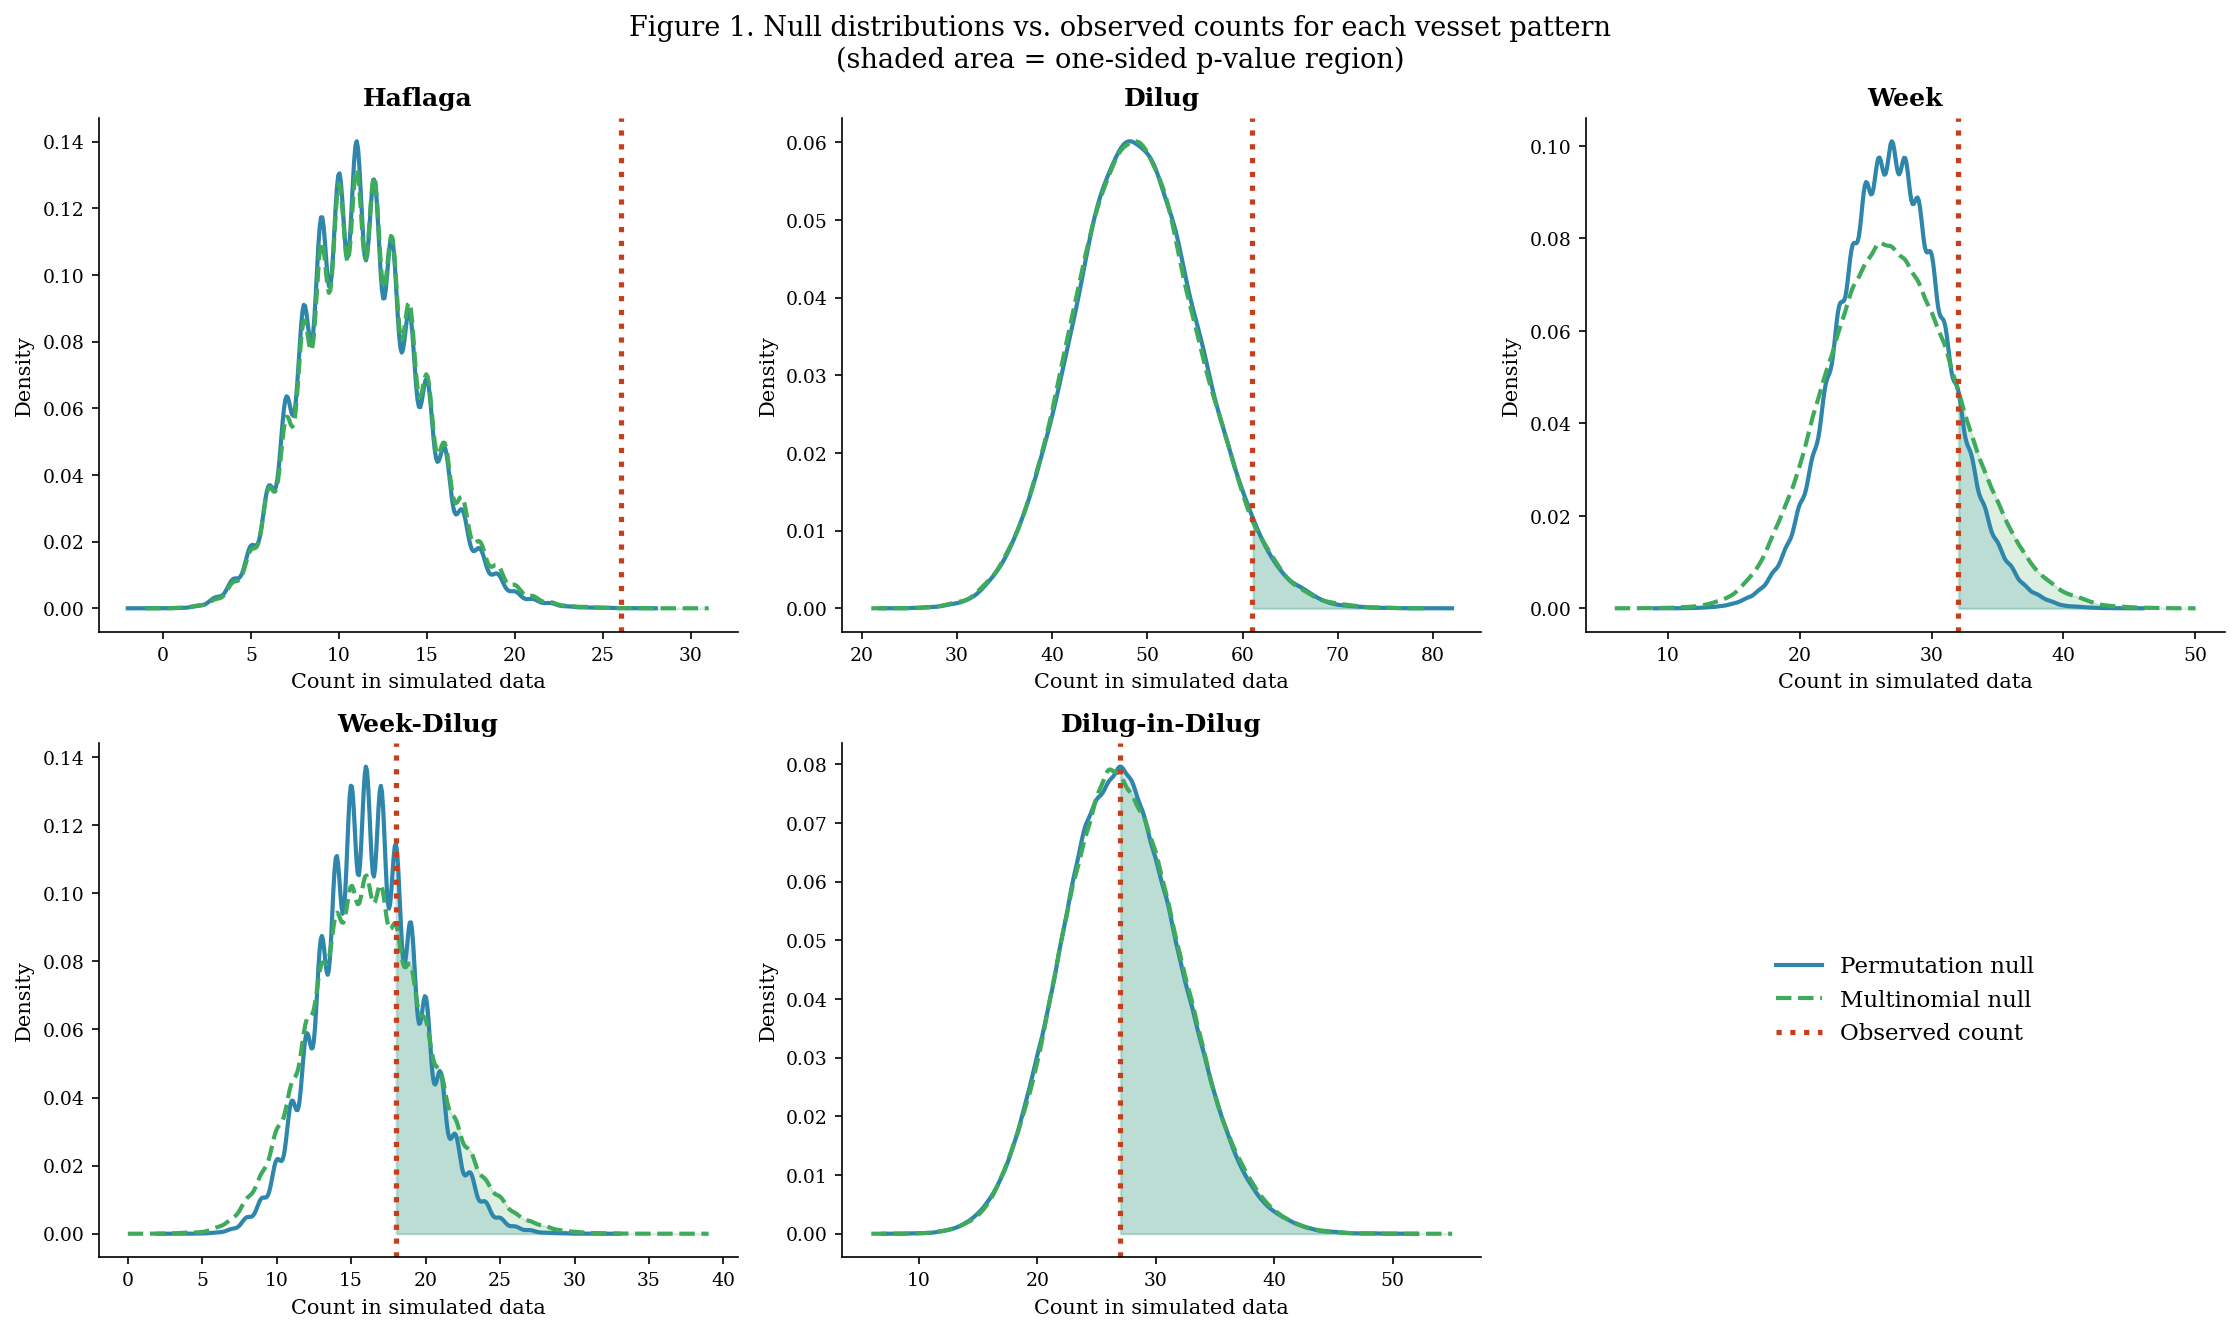

Saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, label in enumerate(PATTERN_LABELS):
    ax = axes[i]; obs = observed[i]
    for method, sim, color, ls in [
        ('Permutation', perm_df,  C_PERM,  '-'),
        ('Multinomial', multi_df, C_MULTI, '--'),
    ]:
        v   = sim[label].values
        kde = stats.gaussian_kde(v)
        xg  = np.linspace(v.min()-2, v.max()+2, 400)
        yg  = kde(xg)
        ax.plot(xg, yg, color=color, lw=2, ls=ls, label=method)
        ax.fill_between(xg[xg>=obs], yg[xg>=obs], alpha=0.18, color=color)
    ax.axvline(obs, color=C_OBS, lw=2.5, ls=':', label=f'Observed = {obs}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Count in simulated data'); ax.set_ylabel('Density')

leg = [Line2D([0],[0], color=C_PERM,  lw=2, ls='-',  label='Permutation null'),
       Line2D([0],[0], color=C_MULTI, lw=2, ls='--', label='Multinomial null'),
       Line2D([0],[0], color=C_OBS,   lw=2.5, ls=':', label='Observed count')]
axes[5].legend(handles=leg, loc='center', fontsize=11, frameon=False)
axes[5].axis('off')

fig.suptitle('Figure 1. Null distributions vs. observed counts for each vesset pattern\n'
             '(shaded area = one-sided p-value region)', fontsize=13)
plt.tight_layout()
plt.savefig('../paper/figures/fig1_null_distributions.pdf', bbox_inches='tight')
plt.savefig('../paper/figures/fig1_null_distributions.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved.')


## 10. Z-Score Comparison

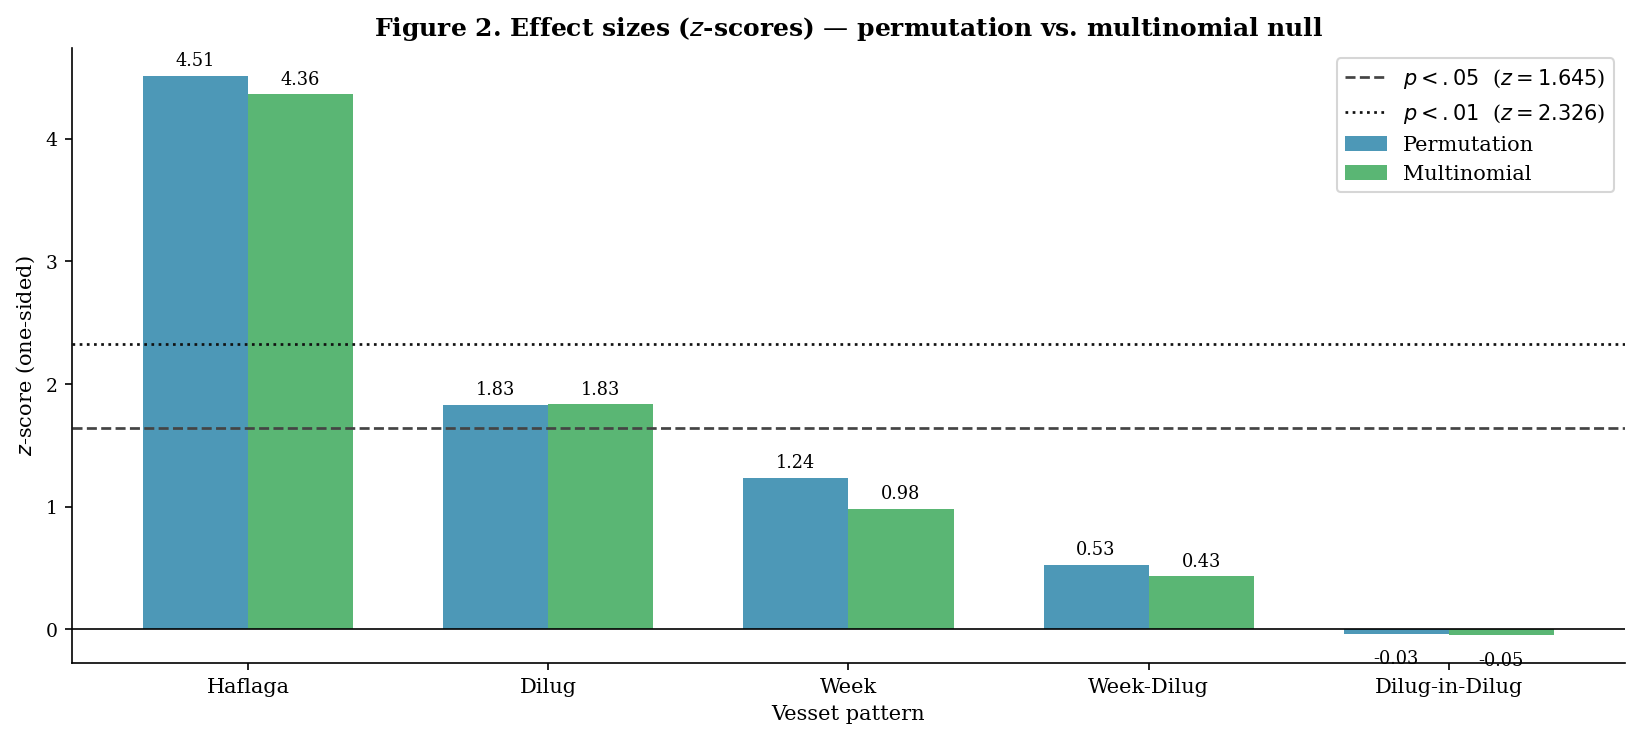

Saved.


In [10]:
pz = [(observed[i]-perm_df[l].mean())/perm_df[l].std(ddof=1)
      for i,l in enumerate(PATTERN_LABELS)]
mz = [(observed[i]-multi_df[l].mean())/multi_df[l].std(ddof=1)
      for i,l in enumerate(PATTERN_LABELS)]

xp = np.arange(len(PATTERN_LABELS)); w = 0.35
fig, ax = plt.subplots(figsize=(11,5))
b1 = ax.bar(xp-w/2, pz, w, label='Permutation', color=C_PERM,  alpha=0.85)
b2 = ax.bar(xp+w/2, mz, w, label='Multinomial', color=C_MULTI, alpha=0.85)
ax.axhline(1.645, color='#444', lw=1.3, ls='--', label='$p<.05$  ($z=1.645$)')
ax.axhline(2.326, color='#111', lw=1.3, ls=':',  label='$p<.01$  ($z=2.326$)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xp); ax.set_xticklabels(PATTERN_LABELS, fontsize=10)
ax.set_ylabel('$z$-score (one-sided)'); ax.set_xlabel('Vesset pattern')
ax.set_title('Figure 2. Effect sizes ($z$-scores) — permutation vs. multinomial null',
             fontweight='bold')
ax.legend(fontsize=10)
for bar in [*b1,*b2]:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.05 if h>=0 else h-0.28,
            f'{h:.2f}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.savefig('../paper/figures/fig2_zscores.pdf', bbox_inches='tight')
plt.savefig('../paper/figures/fig2_zscores.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved.')


## 11. Joint Multivariate Test — All 5 Patterns

The joint test statistic is the Euclidean distance of the observed count vector
$\mathbf{O} = (O_1,\ldots,O_5)^\top$ from the null mean vector $\bar{\mathbf{S}}$:
$$D = \|\mathbf{O} - \bar{\mathbf{S}}\|_2$$
The p-value is the fraction of simulated iterations where the simulated distance
exceeded $D$.  This test is an original contribution (Ross, 2022); it is
*inspired by* but distinct from King, Zhang & Akram (2018), who use a multivariate
kernel density estimator to define the acceptance region.  A formal theoretical
treatment of the distance-based approach is planned in future work.


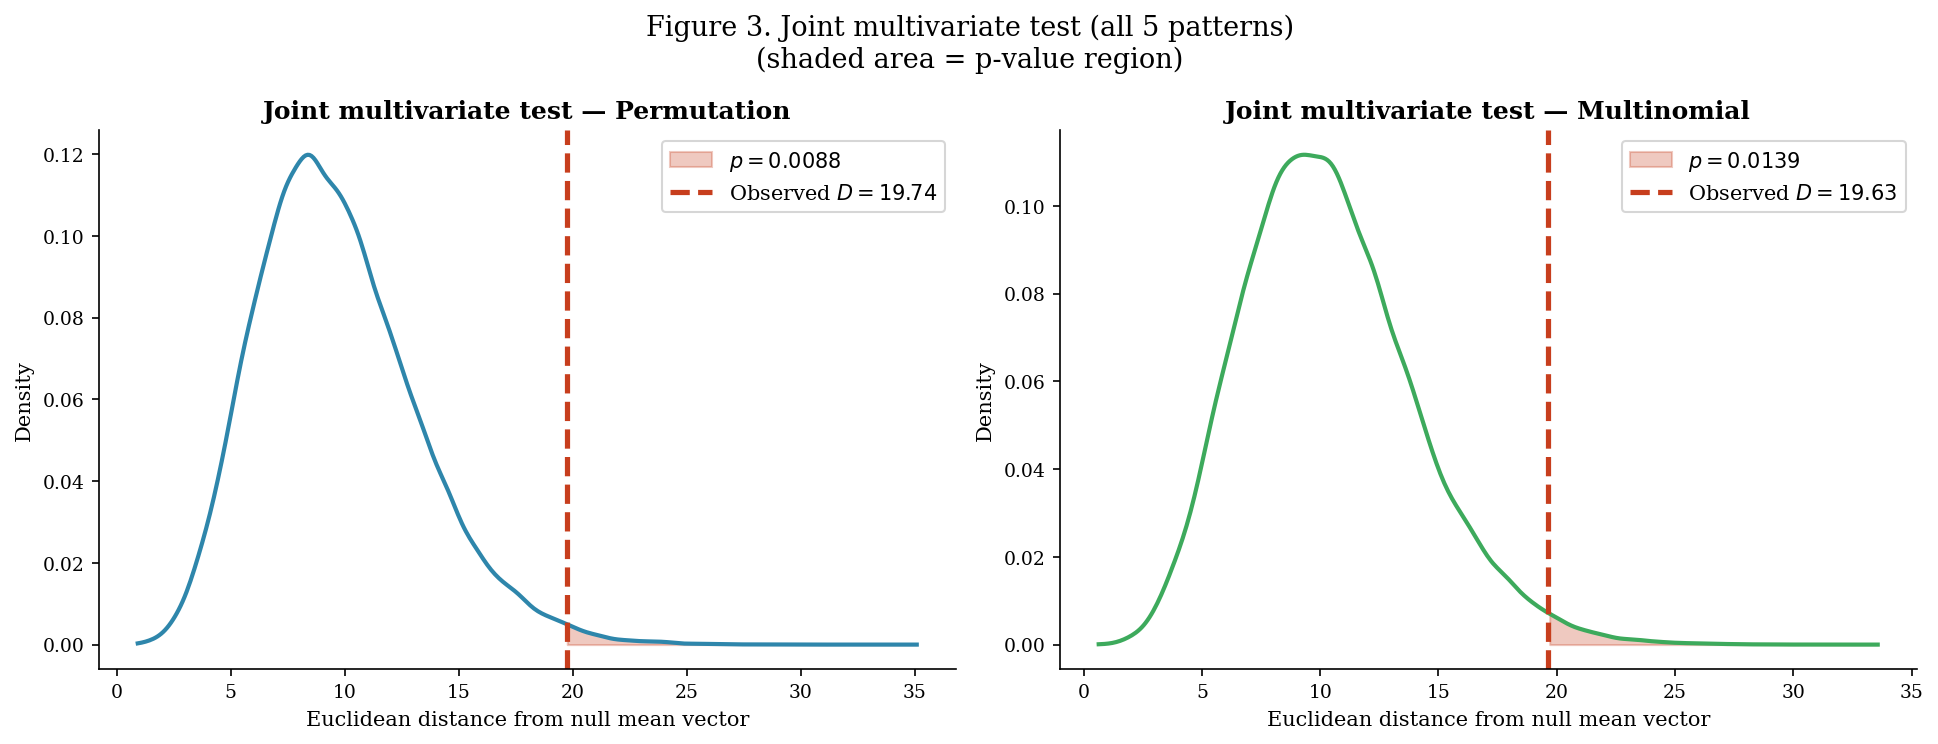


── Joint test summary ──────────────────────────
  Permutation   : D = 19.7355,  p = 0.0088
  Multinomial   : D = 19.6336,  p = 0.0139


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
joint_results = {}

for ax, method, sim, color in [
    (axes[0], 'Permutation', perm_df,  C_PERM),
    (axes[1], 'Multinomial', multi_df, C_MULTI),
]:
    nm     = sim.mean().values
    od     = np.linalg.norm(observed - nm)
    ndists = np.linalg.norm(sim.values - nm, axis=1)
    pval   = (ndists >= od).mean()
    joint_results[method] = {'D': od, 'p': pval}

    kde = stats.gaussian_kde(ndists)
    xg  = np.linspace(ndists.min(), ndists.max()+3, 400)
    yg  = kde(xg)
    ax.plot(xg, yg, lw=2, color=color)
    ax.fill_between(xg[xg>=od], yg[xg>=od], alpha=0.28, color=C_OBS,
                    label=f'$p = {pval:.4f}$')
    ax.axvline(od, color=C_OBS, lw=2.5, ls='--',
               label=f'Observed $D = {od:.2f}$')
    ax.set_title(f'Joint multivariate test — {method}', fontweight='bold')
    ax.set_xlabel('Euclidean distance from null mean vector')
    ax.set_ylabel('Density'); ax.legend(fontsize=10)

fig.suptitle('Figure 3. Joint multivariate test (all 5 patterns)\n'
             '(shaded area = p-value region)', fontsize=13)
plt.tight_layout()
plt.savefig('../paper/figures/fig3_joint_test.pdf', bbox_inches='tight')
plt.savefig('../paper/figures/fig3_joint_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Joint test summary ──────────────────────────')
for method, res in joint_results.items():
    print(f'  {method:14s}: D = {res["D"]:.4f},  p = {res["p"]:.4f}')


## 12. Empirical CDFs

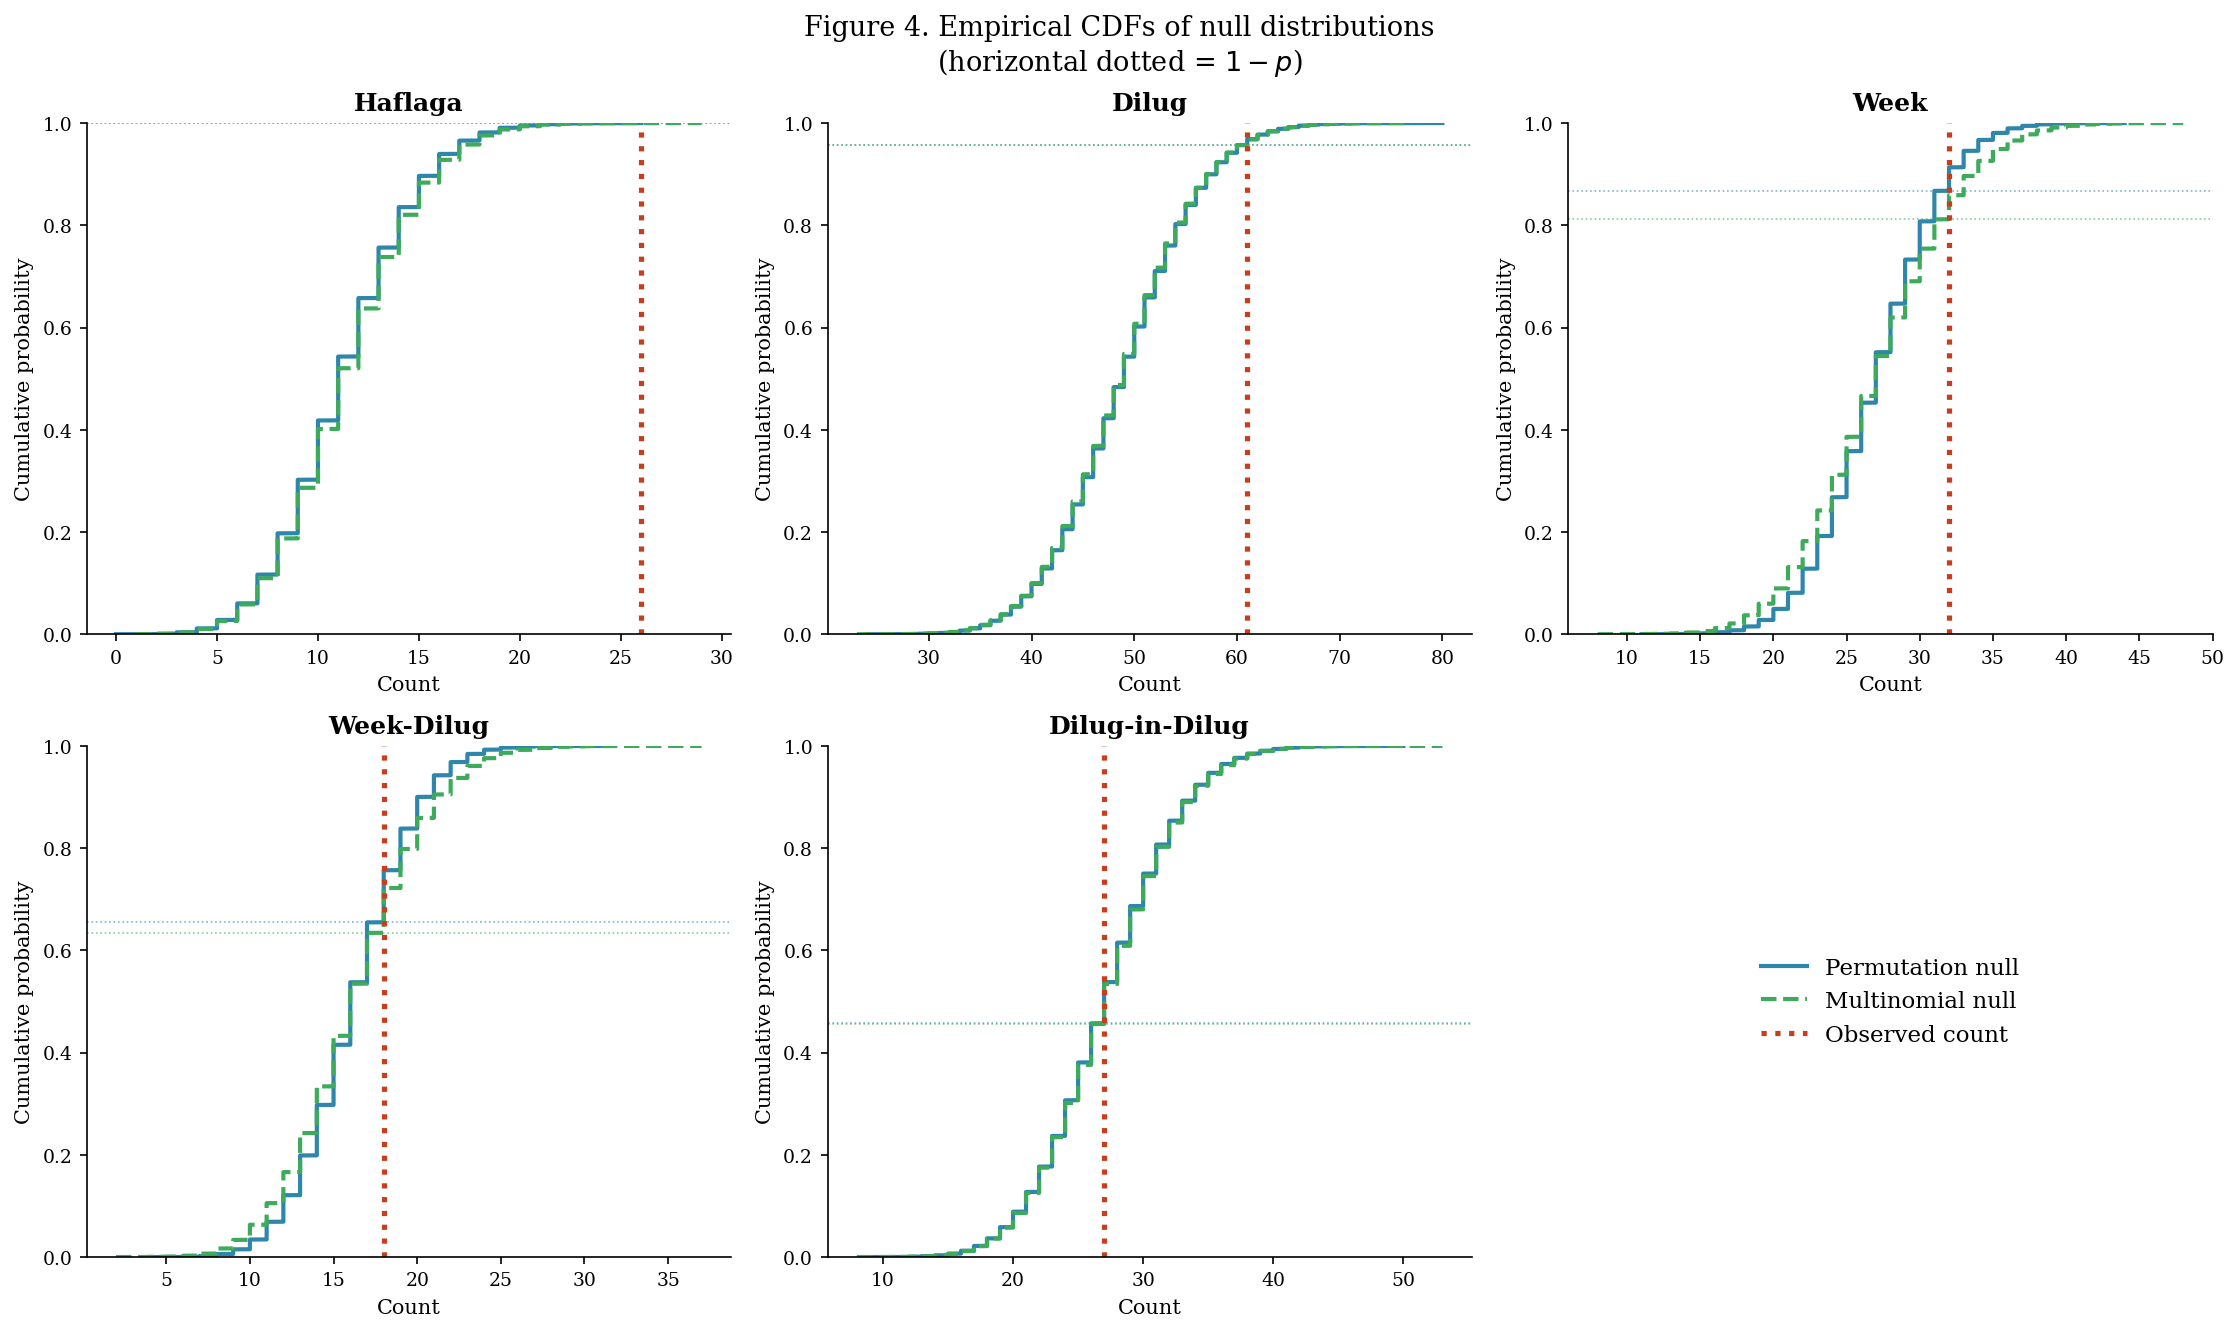

Saved.


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, label in enumerate(PATTERN_LABELS):
    ax = axes[i]; obs = observed[i]
    for method, sim, color, ls in [
        ('Permutation', perm_df,  C_PERM,  '-'),
        ('Multinomial', multi_df, C_MULTI, '--'),
    ]:
        v   = np.sort(sim[label].values)
        cdf = np.arange(1, len(v)+1) / len(v)
        p   = (sim[label] >= obs).mean()
        ax.plot(v, cdf, color=color, lw=2, ls=ls, label=method)
        ax.axhline(1-p, color=color, lw=0.8, ls=':', alpha=0.6)
    ax.axvline(obs, color=C_OBS, lw=2.5, ls=':', label=f'Observed={obs}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Count'); ax.set_ylabel('Cumulative probability')
    ax.set_ylim(0,1)
leg2 = [Line2D([0],[0], color=C_PERM,  lw=2, ls='-',  label='Permutation null'),
        Line2D([0],[0], color=C_MULTI, lw=2, ls='--', label='Multinomial null'),
        Line2D([0],[0], color=C_OBS,   lw=2.5, ls=':', label='Observed count')]
axes[5].legend(handles=leg2, loc='center', fontsize=11, frameon=False)
axes[5].axis('off')
fig.suptitle('Figure 4. Empirical CDFs of null distributions\n'
             '(horizontal dotted = $1-p$)', fontsize=13)
plt.tight_layout()
plt.savefig('../paper/figures/fig4_cdfs.pdf', bbox_inches='tight')
plt.savefig('../paper/figures/fig4_cdfs.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved.')


## 13. Mathematical Dependence Structure

### The polynomial hierarchy of vesset types

The five vesset patterns form a **polynomial hierarchy** based on the degree of the
polynomial that best fits the haflaga sequence:

| Pattern | Condition | Poly. degree |
|---|---|---|
| Week-Dilug | $H_k = 30$ (constant, specific) | 0 |
| Week | $H_k = c \in \mathcal{W}$ (constant, anchored) | 0 |
| Haflaga | $H_k = c$ (constant, any) | 0 |
| Dilug | $\Delta H_k = d \neq 0$ (linear) | 1 |
| Dilug-in-Dilug | $\Delta^2 H_k = d \neq 0$ (quadratic) | 2 |

This hierarchy is not just taxonomic — it generates **mathematically necessary**
relationships between the patterns that directly explain the observed dependence
structure:

---

### Why Haflaga × Week-Dilug: *set-theoretic inclusion*

Week-Dilug requires $H_k = H_{k-1} = 30$ (two consecutive equal haflagot at 30).
Haflaga-30 requires $H_k = H_{k-1} = H_{k-2} = 30$ (three consecutive equal at 30).

Therefore:
$$\{\text{Haflaga-30 sequence}\} \;\subseteq\; \{\text{Week-Dilug sequence}\}$$

Every Haflaga sequence with value 30 *automatically generates* a Week-Dilug event
in its first two cycles.  This is **set-theoretic inclusion**, not just correlation.
Women who establish Haflaga-30 are *guaranteed* to also establish Week-Dilug.

---

### Why Haflaga × Dilug-in-Dilug: *proximity in the polynomial hierarchy*

Dilug-in-Dilug (degree 2) has first differences that form a non-trivial AP:
$\Delta H_k = b, b+d, b+2d, \ldots$ with $d \neq 0$.

When $|d|$ is small, these differences are nearly equal, and the haflaga sequence
is nearly constant — i.e., nearly a **Haflaga**.  The two patterns converge as
$d \to 0$ (the Haflaga is the limiting case $d=0$ of a DiD sequence).

Both patterns also share identical structural requirements:
- A **minimum run length** of $\geq 3$ consecutive cycles
- **Sustained regularity** over that run
- The same **biological substrate**: women with low within-person cycle variability

---

### Why Dilug × Week-Dilug: *logical incompatibility*

Dilug requires $\Delta H_k \neq 0$ (strictly non-constant differences).
Week-Dilug requires $H_k = H_{k-1} = 30$ (zero difference).
These conditions are **mutually exclusive** within the same cycle window:
a pair satisfying Week-Dilug ($\Delta H = 0$) cannot simultaneously satisfy
Dilug's non-constancy requirement.

---

### Implication for the joint test

Because the five pattern counts are **not statistically independent**, Bonferroni
correction (which assumes independence) would be inappropriate and overly conservative.
The joint multivariate test introduced in Section 11 automatically accommodates the
dependence structure by operating on the full count vector simultaneously.


## 14. Chi-Square Dependence Tests (Per-Woman)

In [13]:
# Per-woman binary flags already computed above (per_w_chi from Section 5).
# Now run pairwise chi-square tests.

from itertools import combinations as _combinations
from scipy import stats as _stats

print(f"Women with each pattern established:")
print(per_w_chi[PATTERN_LABELS].sum().to_string())
print(f"Total women: {len(per_w_chi)}\n")

chi_rows = []
for a, b in _combinations(PATTERN_LABELS, 2):
    ct      = pd.crosstab(per_w_chi[a], per_w_chi[b]
               ).reindex(index=[0,1], columns=[0,1], fill_value=0)
    chi2, p, _, exp = _stats.chi2_contingency(ct, correction=False)
    obs_both = ct.loc[1,1]; exp_both = exp[1,1]
    direction = 'positive' if obs_both > exp_both else 'negative'
    sig = '***' if p<.001 else ('**' if p<.01 else ('*' if p<.05 else 'n.s.'))
    chi_rows.append({'Pair':f'{a} × {b}', 'χ²':round(chi2,3), 'p':p,
                     'Obs(1,1)':obs_both, 'Exp(1,1)':round(exp_both,1),
                     'Direction':direction, 'Sig':sig})

chi_df = pd.DataFrame(chi_rows)

def color_sig(val):
    if val in ['***','**','*']: return 'font-weight:bold; color:#C73E1D'
    return ''

display(
    chi_df.style
          .format({'χ²':'{:.3f}','p':'{:.4f}','Exp(1,1)':'{:.1f}'})
          .map(color_sig, subset=['Sig'])
          .set_caption(
              'Table 2. Pairwise chi-square tests of independence between vesset types '
              '(per-woman binary; N=118). * p<.05  ** p<.01  *** p<.001'
          )
)


Women with each pattern established:
Haflaga           20
Dilug             48
Week              26
Week-Dilug        18
Dilug-in-Dilug    23
Total women: 118



,Pair,χ²,p,"Obs(1,1)","Exp(1,1)",Direction,Sig
0,Haflaga × Dilug,0.867,0.3517,10,8.1,positive,n.s.
1,Haflaga × Week,0.890,0.3456,6,4.4,positive,n.s.
2,Haflaga × Week-Dilug,7.263,0.0070,7,3.1,positive,**
3,Haflaga × Dilug-in-Dilug,9.985,0.0016,9,3.9,positive,**
4,Dilug × Week,2.396,0.1216,14,10.6,positive,n.s.
5,Dilug × Week-Dilug,1.465,0.2262,5,7.3,negative,n.s.
6,Dilug × Dilug-in-Dilug,0.093,0.7606,10,9.4,positive,n.s.
7,Week × Week-Dilug,0.408,0.5230,5,4.0,positive,n.s.
8,Week × Dilug-in-Dilug,1.174,0.2787,7,5.1,positive,n.s.
9,Week-Dilug × Dilug-in-Dilug,0.929,0.3350,5,3.5,positive,n.s.


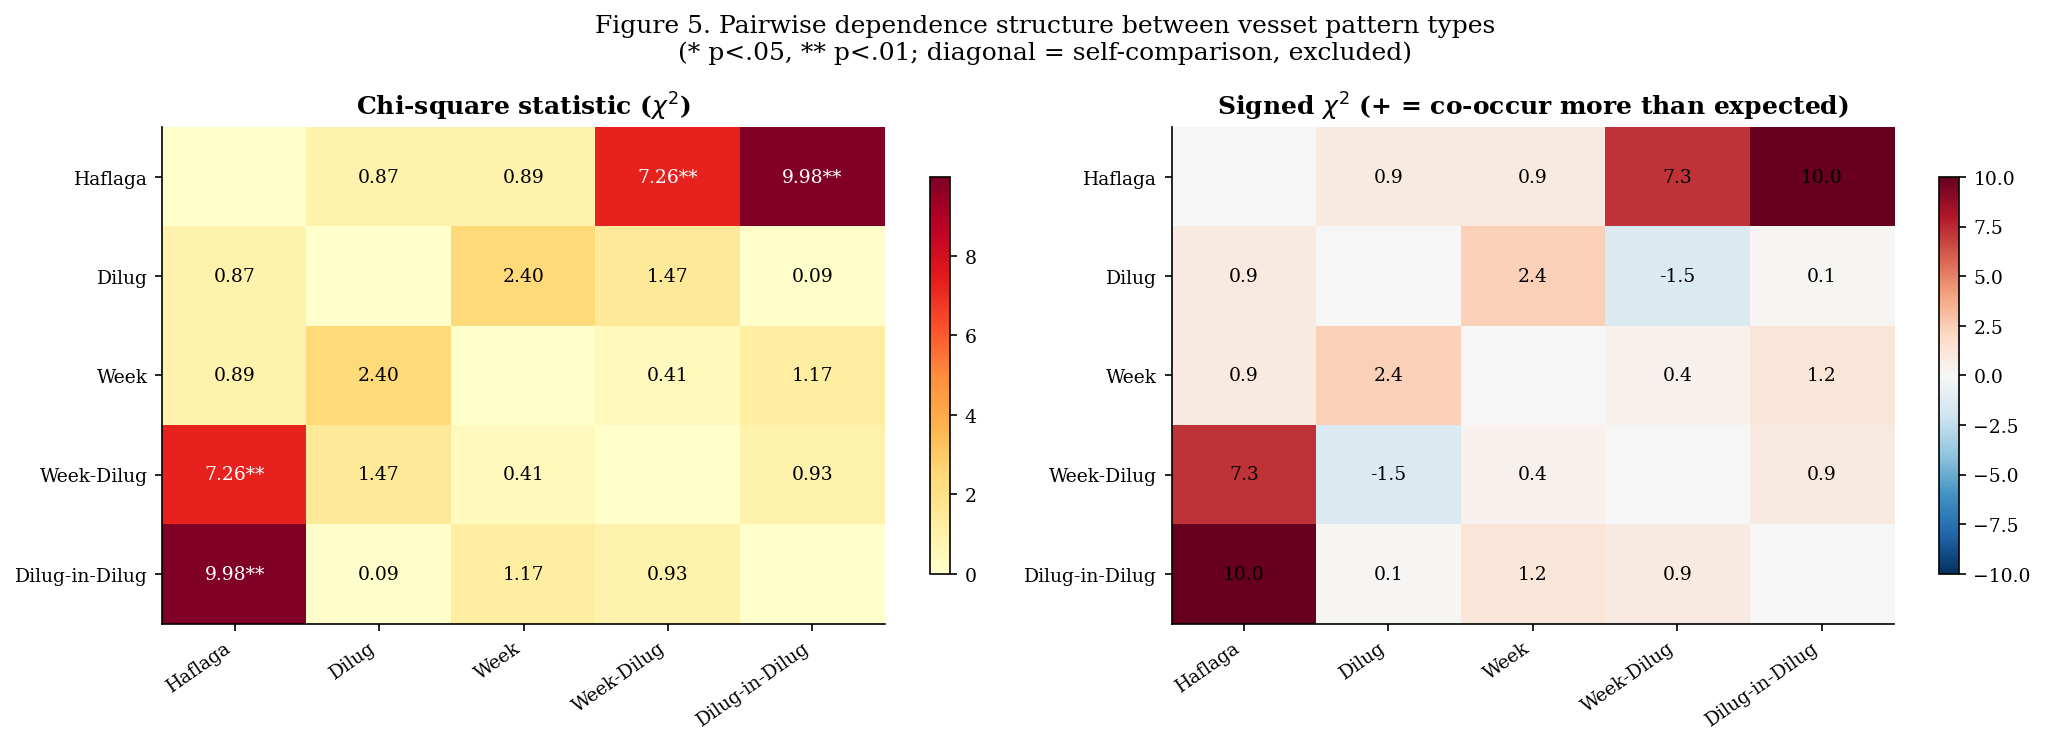

Saved.


In [14]:
# ── Heatmap of chi-square statistics ─────────────────────────────────────────
chi_mat = pd.DataFrame(np.zeros((5,5)), index=PATTERN_LABELS, columns=PATTERN_LABELS)
p_mat   = pd.DataFrame(np.ones((5,5)),  index=PATTERN_LABELS, columns=PATTERN_LABELS)

for row in chi_rows:
    a, b = row['Pair'].split(' × ')
    chi_mat.loc[a,b] = chi_mat.loc[b,a] = row['χ²']
    p_mat.loc[a,b]   = p_mat.loc[b,a]   = row['p']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chi-square heatmap
im1 = axes[0].imshow(chi_mat.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(PATTERN_LABELS, rotation=35, ha='right')
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(PATTERN_LABELS)
axes[0].set_title('Chi-square statistic ($\chi^2$)', fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)
for i in range(5):
    for j in range(5):
        if i != j:
            sig = '**' if p_mat.iloc[i,j] < 0.01 else ('*' if p_mat.iloc[i,j] < 0.05 else '')
            axes[0].text(j, i, f"{chi_mat.iloc[i,j]:.2f}{sig}",
                        ha='center', va='center', fontsize=9,
                        color='white' if chi_mat.iloc[i,j] > 5 else 'black')

# Direction heatmap (positive = women co-occur more than expected)
dir_mat = np.zeros((5,5))
for row in chi_rows:
    a, b = row['Pair'].split(' × ')
    ai, bi = PATTERN_LABELS.index(a), PATTERN_LABELS.index(b)
    v = row['χ²'] if row['Direction']=='positive' else -row['χ²']
    dir_mat[ai,bi] = dir_mat[bi,ai] = v

im2 = axes[1].imshow(dir_mat, cmap='RdBu_r', aspect='auto',
                     vmin=-10, vmax=10)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(PATTERN_LABELS, rotation=35, ha='right')
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(PATTERN_LABELS)
axes[1].set_title('Signed $\chi^2$ (+ = co-occur more than expected)', fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)
for i in range(5):
    for j in range(5):
        if i != j:
            axes[1].text(j, i, f"{dir_mat[i,j]:.1f}",
                        ha='center', va='center', fontsize=9,
                        color='black')

fig.suptitle('Figure 5. Pairwise dependence structure between vesset pattern types\n'
             '(* p<.05, ** p<.01; diagonal = self-comparison, excluded)',
             fontsize=12)
plt.tight_layout()
plt.savefig('../paper/figures/fig5_chisq_heatmap.pdf', bbox_inches='tight')
plt.savefig('../paper/figures/fig5_chisq_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved.')


## 15. Full 5D Joint Test Visualization

The joint test operates in full 5-dimensional space. To visualise all five pattern
counts simultaneously, we plot on three axes the mathematically dependent patterns
(Haflaga, Week-Dilug, Dilug-in-Dilug) and encode the remaining two as:
- **Marker size** → Dilug count
- **Marker color** → Week count

This encoding choice is motivated by the dependence structure (Section 14):
the three axis patterns are the ones with significant pairwise dependencies, so their
joint displacement is the most informative signal. Dilug and Week, which are not
significantly dependent with the others, serve as the encoded dimensions.

We show both null models side by side to confirm robustness of the visual result.

The arrow identifies the observed vector; its position relative to the null cloud
shows that the displacement is genuine across all five dimensions.


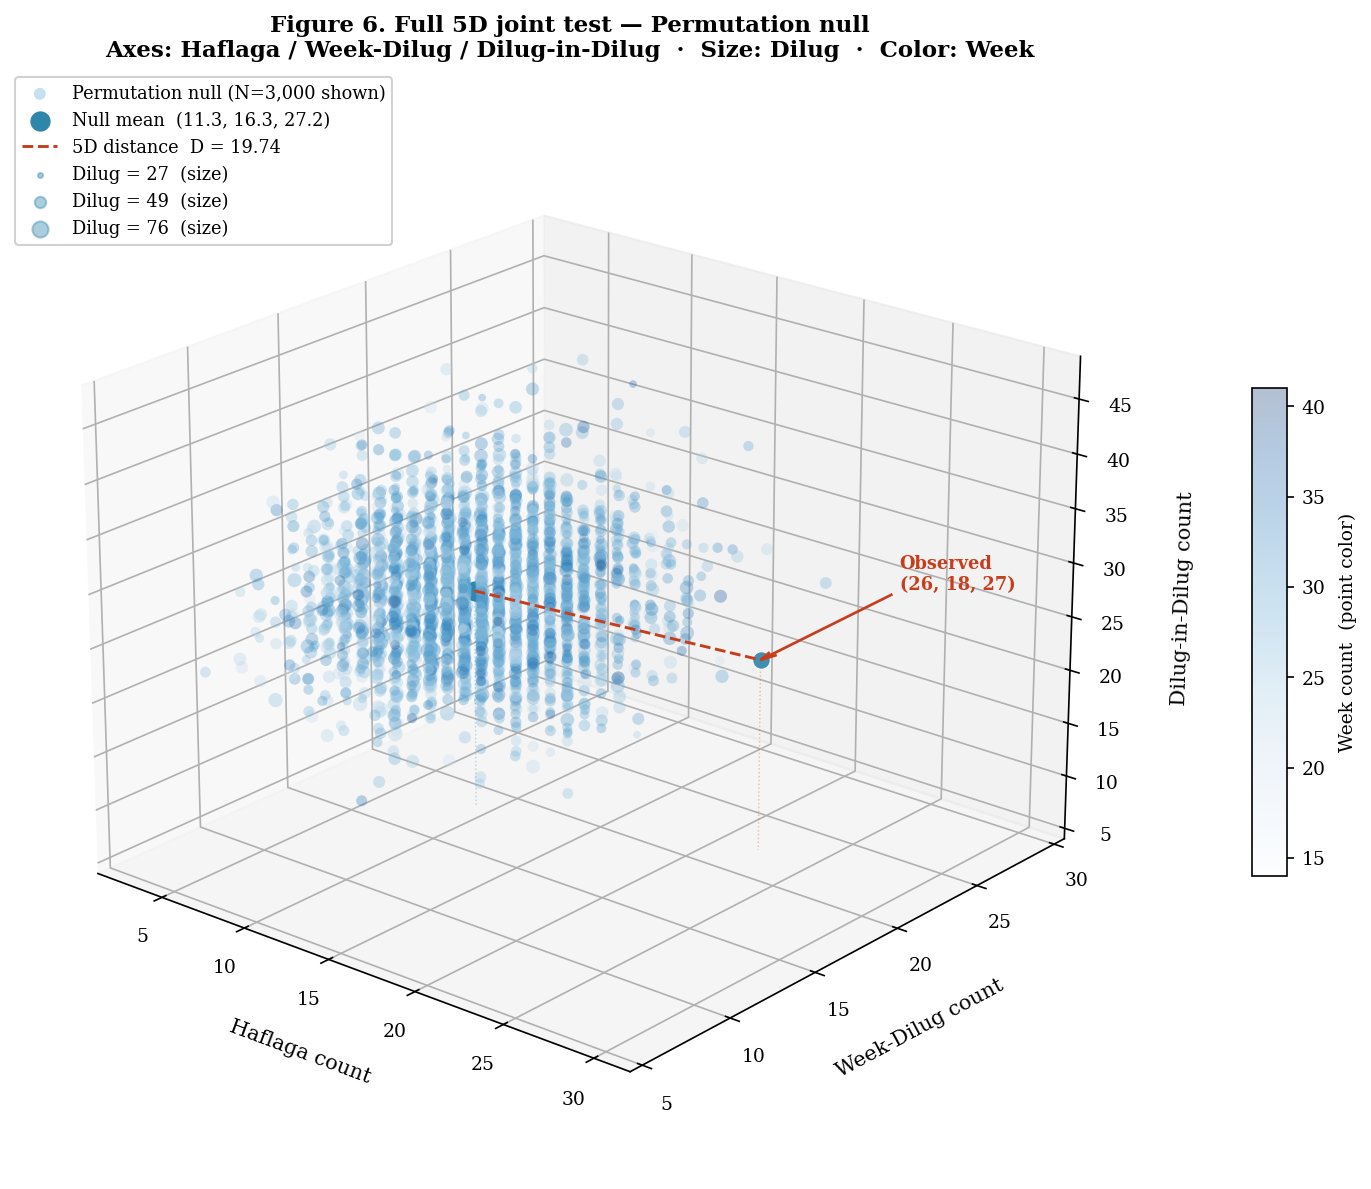

fig6_5d_permutation saved  (D=19.7355)


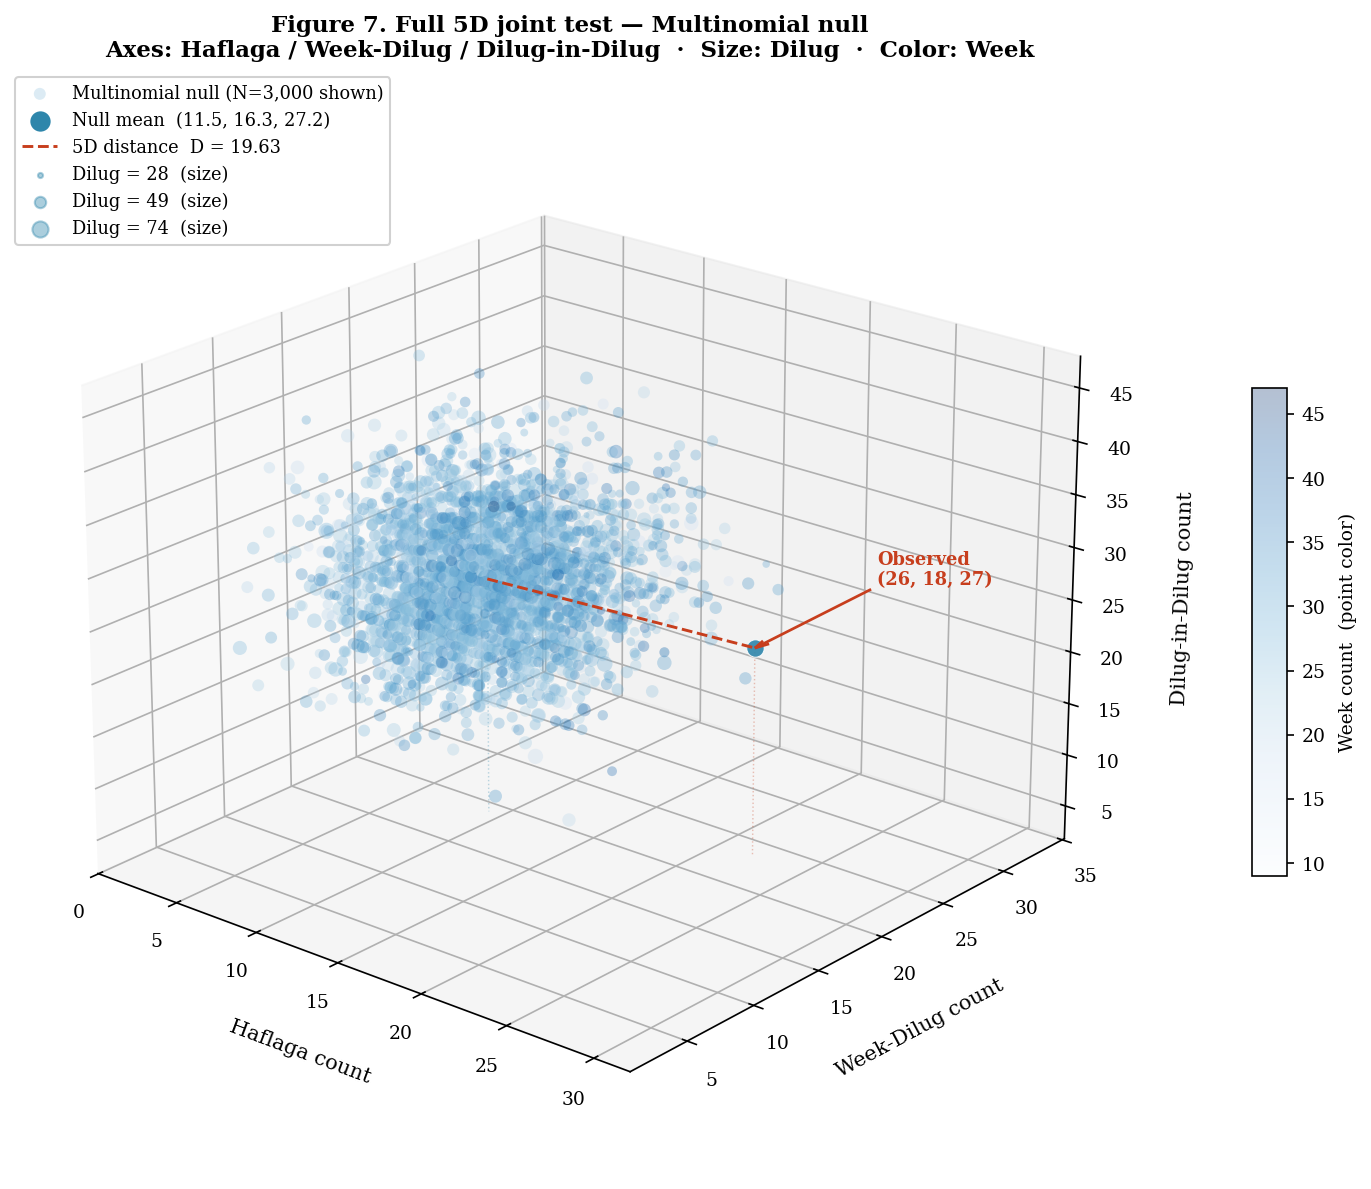

fig7_5d_multinomial saved  (D=19.6336)


In [15]:
def plot_5d_joint(sim_df, method_name, fig_label, ax_title):
    """
    5D joint test visualization.
    Axes: Haflaga(x), Week-Dilug(y), Dilug-in-Dilug(z)
    Size: Dilug,  Color: Week
    """
    null_mean = sim_df.mean().values
    nm_xyz    = np.array([null_mean[0], null_mean[3], null_mean[4]])
    obs_xyz   = np.array([observed[0],  observed[3],  observed[4]], dtype=float)
    dist_5d   = np.linalg.norm(observed.astype(float) - null_mean)

    np.random.seed(42)
    idx  = np.random.choice(len(sim_df), 3000, replace=False)
    sub  = sim_df.iloc[idx]

    x3   = sub['Haflaga'].values
    y3   = sub['Week-Dilug'].values
    z3   = sub['Dilug-in-Dilug'].values
    sz_v = sub['Dilug'].values
    co_v = sub['Week'].values

    sz3  = 6 + 54*(sz_v - sz_v.min())/(sz_v.max()-sz_v.min()+1e-9)
    norm3= mcolors.Normalize(vmin=co_v.min(), vmax=co_v.max())

    fig  = plt.figure(figsize=(12, 8))
    ax   = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x3, y3, z3, c=co_v, cmap='Blues', s=sz3,
                    alpha=0.30, linewidths=0, norm=norm3,
                    label=f'{method_name} null (N=3,000 shown)')

    # Null mean
    ax.scatter(*nm_xyz, color='#2E86AB', s=120, marker='o',
               edgecolors='white', linewidths=1.2, zorder=10,
               label=f'Null mean  ({nm_xyz[0]:.1f}, {nm_xyz[1]:.1f}, {nm_xyz[2]:.1f})')

    # Observed — plain marker + refined arrow
    ax.scatter(*obs_xyz, color='#2E86AB', s=70, marker='o',
               edgecolors='white', linewidths=0.5, alpha=0.9, zorder=11)
    offset = np.array([4.0, 3.5, 5.5])
    tail   = obs_xyz + offset
    ax.quiver(tail[0], tail[1], tail[2],
              obs_xyz[0]-tail[0], obs_xyz[1]-tail[1], obs_xyz[2]-tail[2],
              color='#C73E1D', arrow_length_ratio=0.10, linewidth=1.3, zorder=15)
    ax.text(tail[0]+0.2, tail[1]+0.2, tail[2]+0.4,
            f'Observed\n({int(obs_xyz[0])}, {int(obs_xyz[1])}, {int(obs_xyz[2])})',
            color='#C73E1D', fontsize=8.5, fontweight='bold', zorder=16)

    # Distance line
    ax.plot([nm_xyz[0], obs_xyz[0]], [nm_xyz[1], obs_xyz[1]], [nm_xyz[2], obs_xyz[2]],
            color='#C73E1D', lw=1.4, ls='--', zorder=12,
            label=f'5D distance  D = {dist_5d:.2f}')

    for pt, col in [(obs_xyz, '#C73E1D'), (nm_xyz, '#2E86AB')]:
        ax.plot([pt[0],pt[0]], [pt[1],pt[1]], [pt[2], ax.get_zlim()[0]],
                color=col, lw=0.7, ls=':', alpha=0.30)

    sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm3)
    sm.set_array([])
    cbar = fig.colorbar(sc, ax=ax, shrink=0.45, pad=0.08, aspect=14)
    cbar.set_label('Week count  (point color)', fontsize=9, labelpad=6)

    for dil_val, s_val in [(int(sz_v.min()), 6), (int(np.median(sz_v)), 30), (int(sz_v.max()), 60)]:
        ax.scatter([], [], [], s=s_val, c='#2E86AB', alpha=0.4,
                   label=f'Dilug = {dil_val}  (size)')

    ax.set_xlabel('Haflaga count',        labelpad=10)
    ax.set_ylabel('Week-Dilug count',     labelpad=10)
    ax.set_zlabel('Dilug-in-Dilug count', labelpad=10)
    ax.set_title(
        f'{ax_title}\n'
        'Axes: Haflaga / Week-Dilug / Dilug-in-Dilug  ·  Size: Dilug  ·  Color: Week',
        fontsize=11, pad=16, fontweight='bold'
    )
    ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9,
              bbox_to_anchor=(-0.02, 1.02))
    ax.view_init(elev=22, azim=-50)
    plt.tight_layout()
    plt.savefig(f'../paper/figures/{fig_label}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'../paper/figures/{fig_label}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'{fig_label} saved  (D={dist_5d:.4f})')

plot_5d_joint(perm_df,  'Permutation', 'fig6_5d_permutation',
              'Figure 6. Full 5D joint test — Permutation null')
plot_5d_joint(multi_df, 'Multinomial',  'fig7_5d_multinomial',
              'Figure 7. Full 5D joint test — Multinomial null')


## 16. Complete Results Summary

In [16]:
print('=' * 68)
print(f'{"Pattern":<20} {"Method":<14} {"Obs":>4} {"Mean":>7} '
      f'{"SD":>6} {"z":>7} {"p":>9}')
print('-' * 68)
for _, row in summary.iterrows():
    sig = '**' if row['p-value']<0.01 else ('*' if row['p-value']<0.05 else '')
    print(f'{row["Pattern"]:<20} {row["Method"]:<14} {int(row["Observed"]):>4} '
          f'{row["Null Mean"]:>7.2f} {row["Null SD"]:>6.2f} '
          f'{row["Z-score"]:>7.3f} {row["p-value"]:>8.5f} {sig}')
print('=' * 68)
print('** p<.01   * p<.05  (one-sided)')

print()
print('Joint multivariate test (all 5 patterns):')
for method, res in joint_results.items():
    print(f'  {method:14s}: D = {res["D"]:.4f},  p = {res["p"]:.4f}')

print()
print('Key finding: Haflaga sits at/near the ceiling of the permutation null.')
print(f'  Permutation: {(perm_df["Haflaga"]>=26).sum()} of {N_ITER:,} simulations reached ≥ 26')
print(f'  Multinomial: {(multi_df["Haflaga"]>=26).sum()} of {N_ITER:,} simulations reached ≥ 26')


Pattern              Method          Obs    Mean     SD       z         p
--------------------------------------------------------------------
Haflaga              Permutation      26   11.30   3.26   4.511  0.00004 **
Haflaga              Multinomial      26   11.48   3.33   4.360  0.00010 **
Dilug                Permutation      61   48.93   6.60   1.830  0.04324 *
Dilug                Multinomial      61   48.85   6.63   1.834  0.04304 *
Week                 Permutation      32   27.02   4.02   1.238  0.13268 
Week                 Multinomial      32   27.09   5.00   0.981  0.18842 
Week-Dilug           Permutation      18   16.27   3.27   0.529  0.34526 
Week-Dilug           Multinomial      18   16.30   3.92   0.434  0.36580 
Dilug-in-Dilug       Permutation      27   27.17   5.03  -0.033  0.54274 
Dilug-in-Dilug       Multinomial      27   27.23   5.04  -0.046  0.54422 
** p<.01   * p<.05  (one-sided)

Joint multivariate test (all 5 patterns):
  Permutation   : D = 19.7355,  p = 